In [34]:
#Using Logistic Regression
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score , recall_score, f1_score, confusion_matrix

In [35]:
employee_data = pd.read_csv("employee_turnover.csv")
employee_data

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,0.914733,0.965914,0.147215,0.686677,0.251346,0.572003,0.089679,0.127247,0.125553,0.346950,0.450783,0.754675,0.905320,0.203205,0.340194,1
1346,0.396906,0.182952,0.877941,0.824077,0.774960,0.057290,0.556719,0.235014,0.119685,0.781613,0.211581,0.500812,0.526096,0.044767,0.105962,1
1347,0.099171,0.363498,0.849120,0.462270,0.763922,0.585370,0.975760,0.557090,0.782690,0.384706,0.449095,0.270280,0.253656,0.201686,0.121381,1
1348,0.048193,0.453892,0.640611,0.335230,0.952724,0.638797,0.993664,0.801292,0.510281,0.164325,0.649934,0.151225,0.405705,0.422414,0.098286,1


In [36]:
employee_data.head()
employee_data.shape
employee_data.describe()
employee_data.info()
employee_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                             1350 no

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

<Axes: xlabel='Job_Satisfaction', ylabel='Annual_Bonus'>

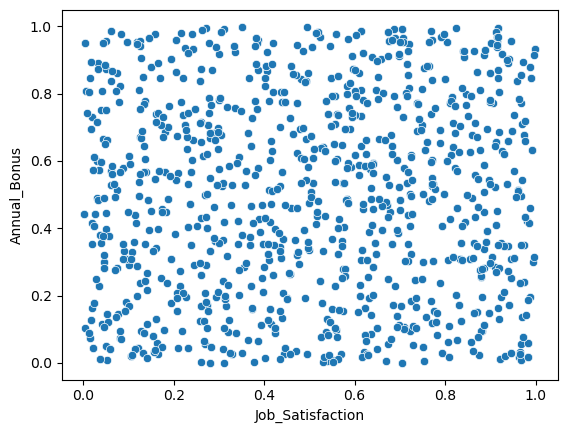

In [37]:
sns.scatterplot(x= employee_data["Job_Satisfaction"], y = employee_data["Annual_Bonus"])

In [38]:
x = employee_data.drop("Employee_Turnover", axis=1)
y = employee_data["Employee_Turnover"]

In [39]:
y.tail()
x.tail()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction
1345,0.914733,0.965914,0.147215,0.686677,0.251346,0.572003,0.089679,0.127247,0.125553,0.346950,0.450783,0.754675,0.905320,0.203205,0.340194
1346,0.396906,0.182952,0.877941,0.824077,0.774960,0.057290,0.556719,0.235014,0.119685,0.781613,0.211581,0.500812,0.526096,0.044767,0.105962
1347,0.099171,0.363498,0.849120,0.462270,0.763922,0.585370,0.975760,0.557090,0.782690,0.384706,0.449095,0.270280,0.253656,0.201686,0.121381
1348,0.048193,0.453892,0.640611,0.335230,0.952724,0.638797,0.993664,0.801292,0.510281,0.164325,0.649934,0.151225,0.405705,0.422414,0.098286
1349,0.496702,0.523527,0.779612,0.320897,0.048957,0.637470,0.908619,0.587263,0.236790,0.265646,0.358821,0.870967,0.828226,0.128753,0.312521


In [40]:
#Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2 , random_state=42
    
)

In [41]:
#create model
model = LogisticRegression(max_iter=1000) 
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred = model.predict(x_test)

In [43]:
y_pred

array([0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0])

In [44]:
y_test

289     0
1036    0
535     1
346     0
1075    0
       ..
1280    1
435     0
722     0
54      1
382     0
Name: Employee_Turnover, Length: 270, dtype: int64

In [45]:
print("accuracy: ", accuracy_score(y_test, y_pred)*100, "%")
print("precision: " , precision_score(y_test, y_pred)*100, "%")

accuracy:  85.92592592592592 %
precision:  87.17948717948718 %


In [46]:
print("recall score:", recall_score(y_test, y_pred))
print("f1 score:", f1_score(y_test, y_pred))

recall score: 0.816
f1 score: 0.8429752066115702


In [47]:
#Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [50]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("accuracy: ", accuracy_score(y_test, y_pred)*100, "%")
print("precision: ", precision_score(y_test, y_pred)*100, "%")
cm = confusion_matrix(y_test, y_pred)
print(cm)

accuracy:  86.29629629629629 %
precision:  86.66666666666667 %
[[129  16]
 [ 21 104]]


In [51]:
# L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5)
lasso.fit(x_train, y_train)

LogisticRegression(C=0.5, penalty='l1', solver='liblinear')

In [53]:
# L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2', C=1, max_iter=200)
ridge.fit(x_train, y_train)


LogisticRegression(C=1, max_iter=200)

In [57]:
# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report

models = {'Baseline': model, 'Lasso': lasso, 'Ridge': ridge}

for name, model in models.items():
    y_pred = model.predict(x_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Baseline
Accuracy: 0.8629629629629629
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       145
           1       0.87      0.83      0.85       125

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270


Lasso
Accuracy: 0.8555555555555555
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       145
           1       0.86      0.82      0.84       125

    accuracy                           0.86       270
   macro avg       0.86      0.85      0.85       270
weighted avg       0.86      0.86      0.86       270


Ridge
Accuracy: 0.8629629629629629
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       145
           1       0.87      0.83      0.85       125

    accuracy                           0.86       270
   macro avg     